# 07 - Multi-Hypothesis Prediction

## Imports

In [1]:
import warnings
# Same known benign numpy 2.x + Apple Accelerate BLAS quirk as 06 - spurious
# RuntimeWarnings on some matmuls with no actual NaN/Inf in the result.
warnings.filterwarnings('ignore', category=RuntimeWarning)

import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## The Problem With One Answer

`06-trajectory-prediction.ipynb` scored a single predicted path against ADE and FDE - both of which assume there's exactly one correct future to compare against. `perception_primer/05` motivated trajectory prediction in the first place with *"a ball could get knocked off course by another ball or a robot"* - but some situations are more specifically ambiguous than that: an opponent robot deciding to juke left or right to get around a defender is often a genuine coin flip from our point of view, not just noisy motion around one true path. If both outcomes are truly equally likely given everything we've observed, no single predicted path can be *right* - one that predicts left is wrong half the time by design, and one that hedges by predicting straight down the middle is wrong *all* the time, since the object never actually goes straight down the middle.

## A Genuinely Ambiguous Dataset

We'll generate trajectories where a robot drives straight for the history window, then a coin flip - decided *after* the history ends, so nothing in what we observed could have predicted it - sends it into a hard turn left or right for the whole prediction horizon.

One simplification, made for a good reason: we'll only ask the model to predict the **lateral** (sideways) offset at each future step, not the full $(x, y)$ position. Forward progress along the original heading isn't actually ambiguous here - it's already well-described by constant velocity, the same baseline `06` used. The only genuinely uncertain quantity is *which way* the path bends, so that's the only thing worth asking the model to predict.

In [2]:
DT = 0.1
K = 5             # history window
M = 5             # prediction horizon
NOISE_STD = 0.02
TURN_RATE = 1.2   # rad/s, same magnitude for both branches - only the sign differs

def generate_ambiguous_trajectory(rng):
    speed = 1.0
    heading, x, y = 0.0, 0.0, 0.0
    positions = []
    branch = rng.choice([-1, 1])   # decided once, but never revealed during the history
    for t in range(K + M):
        positions.append((x + rng.normal(0, NOISE_STD), y + rng.normal(0, NOISE_STD)))
        angular_velocity = 0.0 if t < K else branch * TURN_RATE
        heading += angular_velocity * DT
        x += speed * DT * np.cos(heading)
        y += speed * DT * np.sin(heading)
    return np.array(positions), branch

def make_dataset(n, rng):
    xs, ys, branches = [], [], []
    for _ in range(n):
        trajectory, branch = generate_ambiguous_trajectory(rng)
        history, future = trajectory[:K], trajectory[K:K + M]
        anchor = history[-1]
        xs.append((history - anchor).flatten())
        ys.append(future[:, 1] - anchor[1])   # lateral offset only
        branches.append(branch)
    return np.array(xs).T, np.array(ys).T, np.array(branches)

rng = np.random.default_rng(1515)
X_train, Y_train, branch_train = make_dataset(2000, rng)
X_test, Y_test, branch_test = make_dataset(200, rng)
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"Branch balance: {np.mean(branch_train == 1):.2f} left / {np.mean(branch_train == -1):.2f} right")
print(f"True final lateral offset, left branch:  {Y_train[-1, branch_train == 1].mean():+.4f}")
print(f"True final lateral offset, right branch: {Y_train[-1, branch_train == -1].mean():+.4f}")

X_train: (10, 2000), Y_train: (5, 2000)
Branch balance: 0.49 left / 0.51 right
True final lateral offset, left branch:  +0.1157
True final lateral offset, right branch: -0.1182


## Baseline: What a Single-Hypothesis Model Does

Same network shape as `06` - a Regression Head trained by backpropagation - just predicting the lateral offset alone instead of full $(x, y)$.

In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

in_dim, hidden_dim, out_dim = 2 * K, 16, M
W1_single = np.random.randn(hidden_dim, in_dim) * (1 / np.sqrt(in_dim))
b1_single = np.zeros((hidden_dim, 1))
W2_single = np.random.randn(out_dim, hidden_dim) * (1 / np.sqrt(hidden_dim))
b2_single = np.zeros((out_dim, 1))

def forward_single(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    a1 = relu(z1)
    return z1, a1, W2 @ a1 + b2

learning_rate = 0.05
n_train = X_train.shape[1]
for epoch in range(3000):
    z1, a1, prediction = forward_single(X_train, W1_single, b1_single, W2_single, b2_single)
    d_loss = 2 * (prediction - Y_train) / n_train
    d_W2 = d_loss @ a1.T
    d_b2 = np.sum(d_loss, axis=1, keepdims=True)
    d_a1 = W2_single.T @ d_loss
    d_z1 = d_a1 * relu_derivative(z1)
    d_W1 = d_z1 @ X_train.T
    d_b1 = np.sum(d_z1, axis=1, keepdims=True)
    W1_single -= learning_rate * d_W1
    b1_single -= learning_rate * d_b1
    W2_single -= learning_rate * d_W2
    b2_single -= learning_rate * d_b2

_, _, single_prediction = forward_single(X_test, W1_single, b1_single, W2_single, b2_single)
single_ade = np.mean(np.abs(single_prediction - Y_test))
single_fde = np.mean(np.abs(single_prediction[-1] - Y_test[-1]))
print(f"Single-hypothesis ADE: {single_ade:.4f}, FDE: {single_fde:.4f}")
print(f"Single-hypothesis average final lateral prediction: {single_prediction[-1].mean():+.4f}")
print("(true branches are approximately +0.12 and -0.12 - neither is 0)")

Single-hypothesis ADE: 0.0541, FDE: 0.1192
Single-hypothesis average final lateral prediction: -0.0030
(true branches are approximately +0.12 and -0.12 - neither is 0)


The model's average final prediction should land close to **zero** - dead straight down the middle, matching *neither* real branch. This is **mode averaging**: since squared error is minimized by the conditional mean, and the two branches are mirror images of each other, the mean of "turned left" and "turned right" is "didn't turn at all," which is not a real outcome that ever happens.

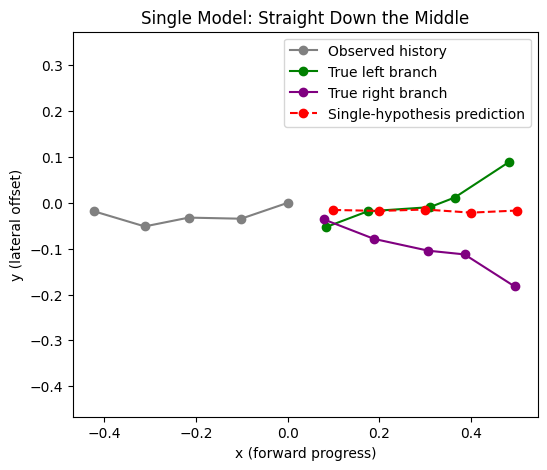

In [4]:
# Build one example trajectory for each branch, for plotting - both drawn from the same
# kind of (noisy, straight) history, so the only real difference is which way they turn.
def draw_trajectory_with_branch(rng, target_branch):
    while True:
        trajectory, branch = generate_ambiguous_trajectory(rng)
        if branch == target_branch:
            return trajectory

traj_left = draw_trajectory_with_branch(np.random.default_rng(42), target_branch=1)
traj_right = draw_trajectory_with_branch(np.random.default_rng(43), target_branch=-1)
anchor = traj_left[K - 1]
x_input = (traj_left[:K] - anchor).flatten().reshape(-1, 1)
_, _, single_pred_here = forward_single(x_input, W1_single, b1_single, W2_single, b2_single)

plt.figure(figsize=(6, 5))
plt.plot(traj_left[:K, 0] - anchor[0], traj_left[:K, 1] - anchor[1], 'o-', color='gray', label='Observed history')
plt.plot(traj_left[K:, 0] - anchor[0], traj_left[K:, 1] - anchor[1], 'o-', color='green', label='True left branch')
plt.plot(traj_right[K:, 0] - anchor[0], traj_right[K:, 1] - anchor[1], 'o-', color='purple', label='True right branch')
plt.plot(traj_left[K-1, 0] - anchor[0] + np.arange(1, M+1) * 1.0 * DT,
         single_pred_here.flatten(), 'o--', color='red', label='Single-hypothesis prediction')
plt.xlabel('x (forward progress)')
plt.ylabel('y (lateral offset)')
plt.title('Single Model: Straight Down the Middle')
plt.legend()
plt.axis('equal')
plt.show()

## Multi-Hypothesis Prediction: K Output Heads Plus a Classifier

Instead of one output head, give the network **two** independent position-prediction heads sharing the same hidden layer, plus one small **classification head** - logits through softmax, exactly the Policy Network shape from `deep_learning_primer/02` and `rl_primer/02-policy-gradients.ipynb` - predicting how likely each hypothesis is to be the right one.

In [5]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

N_HYPOTHESES = 2
W1 = np.random.randn(hidden_dim, in_dim) * (1 / np.sqrt(in_dim))
b1 = np.zeros((hidden_dim, 1))
W2_heads = [np.random.randn(out_dim, hidden_dim) * (1 / np.sqrt(hidden_dim)) for _ in range(N_HYPOTHESES)]
b2_heads = [np.zeros((out_dim, 1)) for _ in range(N_HYPOTHESES)]

# Deliberately spread the heads' initial predictions apart (one nudged positive, one
# negative) instead of leaving them purely to random initialization - see the note below
# on why this matters.
for h in range(N_HYPOTHESES):
    b2_heads[h][:, 0] = (1 if h == 0 else -1) * 0.1

W_classifier = np.random.randn(N_HYPOTHESES, hidden_dim) * (1 / np.sqrt(hidden_dim))
b_classifier = np.zeros((N_HYPOTHESES, 1))

def forward_multi(x, W1, b1, W2_heads, b2_heads, W_classifier, b_classifier):
    z1 = W1 @ x + b1
    a1 = relu(z1)
    head_predictions = [W2 @ a1 + b2 for W2, b2 in zip(W2_heads, b2_heads)]
    logits = W_classifier @ a1 + b_classifier
    probabilities = softmax(logits)
    return z1, a1, head_predictions, logits, probabilities

## Training With Winner-Take-All Loss

For each training example, find whichever head's prediction is currently *closest* to the true future - the **winner** - and only backpropagate that example's position error through the winning head. The classification head is trained separately, as an ordinary classifier, to predict *which* head wins - using the same cross-entropy gradient shape as `rl_primer/02`'s policy update ($\text{probabilities} - \text{onehot(winner)}$), just supervised here instead of reward-scaled. Over many examples, this lets each head specialize into a different mode of behavior, instead of every head chasing the same averaged target.

One real pitfall, worth naming rather than hiding: **hypothesis collapse**. If one head happens to start even slightly closer to the *overall* average of both branches than the other, it wins more than its fair share of examples early on purely by chance, gets trained on more data as a result, improves faster, and wins even more - a rich-get-richer spiral that can leave one head capturing everything and the other permanently stuck near its random initialization. Leaving both heads to plain random initialization and hoping they specialize on their own hits exactly this failure mode in practice. The fix used above - deliberately spreading the heads' initial predictions apart before training even starts - is a simple version of a real, documented mitigation for this exact problem; more sophisticated approaches exist in the research literature (see Resources).

In [6]:
learning_rate = 0.05
for epoch in range(4000):
    z1, a1, head_predictions, logits, probabilities = forward_multi(
        X_train, W1, b1, W2_heads, b2_heads, W_classifier, b_classifier)

    errors = np.stack([np.sum((hp - Y_train) ** 2, axis=0) for hp in head_predictions])
    winner = np.argmin(errors, axis=0)

    onehot_winner = np.zeros((N_HYPOTHESES, n_train))
    onehot_winner[winner, np.arange(n_train)] = 1.0
    d_logits = (probabilities - onehot_winner) / n_train

    d_W_classifier = d_logits @ a1.T
    d_b_classifier = np.sum(d_logits, axis=1, keepdims=True)
    d_a1_total = W_classifier.T @ d_logits

    d_W2_heads, d_b2_heads = [], []
    for h in range(N_HYPOTHESES):
        winner_mask = (winner == h).astype(float)   # zero out every non-winning example
        d_loss_h = 2 * (head_predictions[h] - Y_train) * winner_mask[None, :] / n_train
        d_W2_heads.append(d_loss_h @ a1.T)
        d_b2_heads.append(np.sum(d_loss_h, axis=1, keepdims=True))
        d_a1_total = d_a1_total + W2_heads[h].T @ d_loss_h

    d_z1 = d_a1_total * relu_derivative(z1)
    d_W1 = d_z1 @ X_train.T
    d_b1 = np.sum(d_z1, axis=1, keepdims=True)

    W1 -= learning_rate * d_W1
    b1 -= learning_rate * d_b1
    W_classifier -= learning_rate * d_W_classifier
    b_classifier -= learning_rate * d_b_classifier
    for h in range(N_HYPOTHESES):
        W2_heads[h] -= learning_rate * d_W2_heads[h]
        b2_heads[h] -= learning_rate * d_b2_heads[h]

print("Training complete.")

Training complete.


## Did It Specialize?

In [7]:
_, _, test_head_predictions, _, test_probabilities = forward_multi(
    X_test, W1, b1, W2_heads, b2_heads, W_classifier, b_classifier)

for h in range(N_HYPOTHESES):
    print(f"Head {h} average final lateral offset: {test_head_predictions[h][-1].mean():+.4f}")
print("(true branches are approximately +0.12 and -0.12)")

print(f"\nClassifier average probabilities: {test_probabilities.mean(axis=1).round(3)}")
print(f"Per-example probability range for head 0: "
      f"{test_probabilities[0].min():.3f} - {test_probabilities[0].max():.3f}")

Head 0 average final lateral offset: +0.1146
Head 1 average final lateral offset: -0.1184
(true branches are approximately +0.12 and -0.12)

Classifier average probabilities: [0.489 0.511]
Per-example probability range for head 0: 0.484 - 0.499


Two things should both be true at once, and they're not the same claim: the two heads should have **specialized** into two distinct final offsets, one near each true branch - and the classifier's probabilities should stay close to **50/50 for every single test example**, not just on average. That second part is the subtle, correct result here: since nothing in the history actually distinguishes which branch is coming, a *well-calibrated* classifier has no business being confident about either one. This is the opposite lesson from `rl_primer/02`'s policy gradient notebook, where the same softmax machinery correctly became confident - there, a genuinely better action existed to learn; here, the two outcomes are equally likely by construction, so correct behavior is staying uncertain, not picking a side.

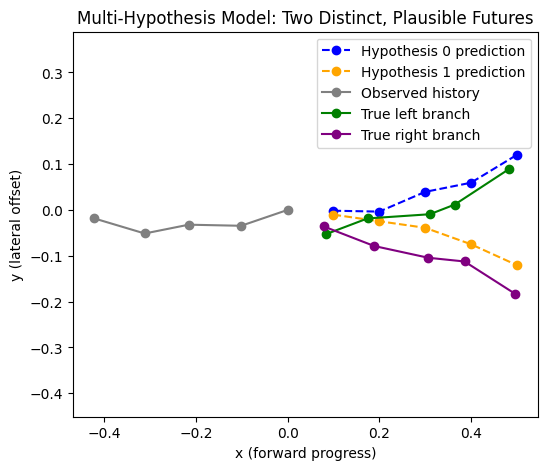

In [8]:
# predict from the shared history window (traj_left's, though either would do - the
# history is what's ambiguous, and both trajectories' histories look statistically alike)
x_input = (traj_left[:K] - anchor).flatten().reshape(-1, 1)
_, _, hypothesis_predictions, _, _ = forward_multi(
    x_input, W1, b1, W2_heads, b2_heads, W_classifier, b_classifier)
future_x = traj_left[K-1, 0] - anchor[0] + np.arange(1, M + 1) * 1.0 * DT

plt.figure(figsize=(6, 5))
for h in range(N_HYPOTHESES):
    color = 'blue' if h == 0 else 'orange'
    plt.plot(future_x, hypothesis_predictions[h].flatten(), 'o--', color=color,
             label=f'Hypothesis {h} prediction')
plt.plot(traj_left[:K, 0] - anchor[0], traj_left[:K, 1] - anchor[1], 'o-', color='gray', label='Observed history')
plt.plot(traj_left[K:, 0] - anchor[0], traj_left[K:, 1] - anchor[1], 'o-', color='green', label='True left branch')
plt.plot(traj_right[K:, 0] - anchor[0], traj_right[K:, 1] - anchor[1], 'o-', color='purple', label='True right branch')
plt.xlabel('x (forward progress)')
plt.ylabel('y (lateral offset)')
plt.title('Multi-Hypothesis Model: Two Distinct, Plausible Futures')
plt.legend()
plt.axis('equal')
plt.show()

## Evaluating With minADE-k / minFDE-k

Scoring a multi-hypothesis model with plain ADE/FDE would unfairly punish it for its *other* heads being wrong about this particular realization. The standard fix in the literature is **minADE-k** / **minFDE-k**: for each test example, only score the *closest* hypothesis, then average that minimum across the test set. This directly answers the question that actually matters downstream - "was at least one of the model's guesses close?" - rather than penalizing it for correctly representing an outcome that didn't happen to occur this time.

In [9]:
head_ade_per_example = [np.mean(np.abs(test_head_predictions[h] - Y_test), axis=0) for h in range(N_HYPOTHESES)]
min_ade = np.mean(np.minimum(*head_ade_per_example))

head_fde_per_example = [np.abs(test_head_predictions[h][-1] - Y_test[-1]) for h in range(N_HYPOTHESES)]
min_fde = np.mean(np.minimum(*head_fde_per_example))

print(f"{'':>20} {'ADE':>8} {'FDE':>8}")
print(f"{'Single-hypothesis':>20} {single_ade:>8.4f} {single_fde:>8.4f}")
print(f"{'Multi-hypothesis (min)':>20} {min_ade:>8.4f} {min_fde:>8.4f}")

                          ADE      FDE
   Single-hypothesis   0.0541   0.1192
Multi-hypothesis (min)   0.0226   0.0244


The multi-hypothesis model's minADE/minFDE should come in well below the single-hypothesis model's plain ADE/FDE - not because it's better at predicting any one specific future, but because it's no longer forced to compress two real, distinct outcomes into one physically-impossible average.

## Try It Yourself

Extend `generate_ambiguous_trajectory` to a **three-way** branch: straight, hard left, or hard right, each equally likely (`rng.choice([-1, 0, 1])`, with `0` meaning no turn at all). Update `N_HYPOTHESES = 3`, resize the initial bias spread across three values instead of two (e.g. `-0.1, 0.0, 0.1`), and retrain. Check both things this notebook checked for two hypotheses: do the three heads specialize into three distinct final offsets, and does the classifier's probability stay close to $1/3$ for every example rather than collapsing onto one or two of the three?

In [10]:
# TODO: extend generate_ambiguous_trajectory to a 3-way branch (left/straight/right),
# set N_HYPOTHESES = 3 with a 3-way initial bias spread, retrain, and check both
# specialization (three distinct final offsets) and calibration (~1/3 each)


## Resources

- Lee, S. et al. (2016). "Stochastic Multiple Choice Learning for Training Diverse Deep Ensembles." *NeurIPS 2016*. The winner-take-all training approach used in this notebook, including a formal treatment of the hypothesis-collapse problem (paper).
- Chai, Y. et al. (2019). "MultiPath: Multiple Probabilistic Anchor Trajectory Hypotheses for Behavior Prediction." A real, production-scale version of exactly this idea, applied to vehicle trajectory prediction (paper).
- [nuScenes Prediction Challenge](https://www.nuscenes.org/prediction) - a real self-driving benchmark that uses minADE-k/minFDE-k as its official scoring metrics, for context on how standard this evaluation approach actually is (benchmark/leaderboard).